In [1]:
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid
import intake
import cf_xarray as cfxr
from access_nri_intake.experiment import use_datastore
from access_nri_intake.source import builders
import os
from xarray import SerializationWarning
import matplotlib.patches as mpatches

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36443,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46175,Total threads: 1
Dashboard: /proxy/33057/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:44033,


In [3]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/argopy/__init__.py:32: DeprecationWarning: The 'argopy.utilities' has moved to 'argopy.utils'. After 0.1.15, importing 'utilities' will raise an error. Please update your script.
  from . import utilities  # noqa: E402  # being deprecated until 0.1.15, then remove
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/core/npstats.py:238: DeprecationWarning: invalid escape sequence '\s'
  """Gaussian frequency spectrum (Bunney et al., 2014).
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.py:25: ResourceWarning: unclosed file <_io.TextIOWrapper name='/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.yml' mode='r' encoding='UTF-8'>
  VAR_ATTRIBUTES = yaml.load(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/w

In [6]:
#rho_400 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/rho_ctrl.nc')
mid_bound = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/bound_mid_mean.nc')

In [7]:
# time period
start_time = '2140-01-01'
end_time = '2164-12-31'

In [8]:
# time period for map
start_time1 = '2160-01-01'
end_time1 = '2164-12-31'

start_time2 = '2151-12-01'
end_time2 = '2154-12-31'

In [9]:
expt_datastore = intake.open_esm_datastore(
    "./ssp585_th.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)


In [10]:
catalog = intake.cat.access_nri

In [11]:
#load T
temp_th = expt_datastore.search(variable="temp",frequency = '1mon').to_dask()
temp_th = temp_th.temp

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [12]:
# read practical salinity
salt_th = expt_datastore.search(variable="salt",frequency = '1mon').to_dask()
salt_th = salt_th.salt

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [13]:

temp_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="temp",frequency = '1mon').to_dask()
temp_ctrl = temp_ctrl.temp

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [14]:
salt_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="salt",frequency = '1mon').to_dask()
salt_ctrl = salt_ctrl.salt

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [15]:
shelf_mask = xr.open_dataarray('/scratch/x77/hm1221/nc_files/shelf_mask.nc')

st_ocean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/st_ocean.nc')

In [16]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

In [17]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [18]:
# calculate the mean state
def temp_400m(temp):
    temp_400 = temp.sel(time = slice(start_time,end_time)).sel(yt_ocean = slice(-90,-50)).sel(st_ocean = 400., method = 'nearest').load()
    temp_400_mean = temp_400.where(shelf_mask<0.8).load()
    temp_400_mean_5yr = temp_400.sel(time = slice(start_time1,end_time1)).mean('time').load()
    temp_400_mean =  temp_400_mean.mean(('xt_ocean','yt_ocean')).load()

    return [temp_400_mean_5yr,temp_400_mean]

In [19]:
temp_400_mean_ctrl_5yr,temp_400_mean_ctrl = temp_400m(temp_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 87.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [20]:
data = xr.Dataset({
    'Control': temp_400_mean_ctrl_5yr
})

In [21]:
# land mask
land = xr.where(np.isnan(temp_400_mean_ctrl_5yr[:,:].rename('land')), 1, np.nan)

In [22]:
def var_mean_5yr(var):
    var_mean_5yr_1 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()
    var_mean_5yr_2 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time2,end_time2)).mean('time').load()
    var_mean_5yr_3 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time3,end_time3)).mean('time').load()
    var_mean_5yr_4 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time4,end_time4)).mean('time').load()
    var_mean_5yr_5 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time5,end_time5)).mean('time').load()
    
    var_season = (var_mean_5yr_1+var_mean_5yr_2+var_mean_5yr_3+var_mean_5yr_4+var_mean_5yr_5)/5.
    return var_season

In [23]:
# for summer
# time period for map
start_time1 = '2159-12-01'
end_time1 = '2160-02-28'
start_time2 = '2160-12-01'
end_time2 = '2161-02-28'
start_time3 = '2161-12-01'
end_time3 = '2162-02-28'
start_time4 = '2162-12-01'
end_time4 = '2163-02-28'
start_time5 = '2163-12-01'
end_time5 = '2164-02-28'

In [24]:
salt_summer = var_mean_5yr(salt_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/c

In [25]:
temp_summer = var_mean_5yr(temp_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/c

In [26]:
#for winter
start_time1 = '2160-06-01'
end_time1 = '2160-08-31'
start_time2 = '2161-06-01'
end_time2 = '2161-08-31'
start_time3 = '2162-06-01'
end_time3 = '2162-08-31'
start_time4 = '2163-06-01'
end_time4 = '2163-08-31'
start_time5 = '2164-06-01'
end_time5 = '2164-08-31'

In [27]:
temp_winter = var_mean_5yr(temp_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/c

In [28]:
salt_winter = var_mean_5yr(salt_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 119.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/c

In [29]:
def var_mean_5yr(var):
    var_mean_5yr = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()

    return var_mean_5yr

In [30]:
# time period for map
start_time1 = '2160-01-01'
end_time1 = '2164-12-31'

In [31]:
temp_th_mean = var_mean_5yr(temp_th)
temp_ctrl_mean = var_mean_5yr(temp_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 313.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 121.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [32]:
salt_th_mean = var_mean_5yr(salt_th)
salt_ctrl_mean = var_mean_5yr(salt_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 313.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 121.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [33]:
def sigma1(temp,salt):
    # practical salinity to absolute salinity
    salt = gsw.conversions.SA_from_SP(salt,salt.st_ocean,salt.xt_ocean,salt.yt_ocean)
    # conservative temp and absolute salinity to sigma1
    rho = gsw.density.sigma1(salt, temp-273.15)

    return rho

In [34]:
rho_ctrl_mean = sigma1(temp_ctrl_mean,salt_ctrl_mean)

In [35]:
rho_ctrl_summer = sigma1(temp_summer,salt_summer)

In [36]:
rho_ctrl_winter = sigma1(temp_winter,salt_winter)

In [37]:
rho_th_mean = sigma1(temp_th_mean,salt_th_mean)

In [38]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [39]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [40]:
temp_ctrl_new,temp_ctrl_mean_new = Trans_lat_to_shelf(temp_ctrl_mean,new_coord)
rho_ctrl_new,rho_ctrl_mean_new = Trans_lat_to_shelf(rho_ctrl_mean,new_coord)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:1283: DeprecationWarning: The `xgcm.Axis` class will be deprecated in the future. Please make sure to use the `xgcm.Grid` methods for your work instead.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:1283: DeprecationWarning: The `xgcm.Axis` class will be deprecated in the future. Please make sure to use the `xgcm.Grid` methods for your work instead.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computa

In [41]:
rho_th_new,rho_th_mean_new = Trans_lat_to_shelf(rho_th_mean,new_coord)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:1283: DeprecationWarning: The `xgcm.Axis` class will be deprecated in the future. Please make sure to use the `xgcm.Grid` methods for your work instead.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


In [ ]:
#rho_th_new_mean= rho_lat_to_shelf(rho_th_mean,new_coord)


# calculate the mld

In [42]:
# time period
start_time_1 = '2163-12-01'
end_time_1 = '2164-02-28'

start_time_2 = '2164-06-01'
end_time_2 = '2164-08-31'

In [43]:
mld_ctrl= catalog['01deg_jra55v13_ryf9091'].search(variable="mld",frequency = '1mon').to_dask()
mld_ctrl = mld_ctrl.mld

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [44]:
mld_summer = mld_ctrl.sel(time = slice(start_time_1,end_time_1)).sel(xt_ocean = -210,method = 'nearest').mean('time').load()
mld_winter =mld_ctrl.sel(time = slice(start_time_2,end_time_2)).sel(xt_ocean = -210,method = 'nearest').mean('time').load()

In [45]:
levs_dens = [32.0,32.3,32.5]
manual_positions = [
    (12, 200), 
    (12, 1000),
    (14,2000)
]

In [46]:
land_2 = xr.where(np.isnan(temp_summer.sel(xt_ocean = -210,method = 'nearest').rename('land')), 1, np.nan)

In [47]:
background = xr.DataArray(
    data=np.ones_like(land_2),
    coords=land_2.coords,
    dims=land_2.dims,
    name='ones_array'
)

<>:71: DeprecationWarning: invalid escape sequence '\c'
<>:71: DeprecationWarning: invalid escape sequence '\c'
<unknown>:71: DeprecationWarning: invalid escape sequence '\c'
/jobfs/162838084.gadi-pbs/ipykernel_1187086/4261169866.py:71: DeprecationWarning: invalid escape sequence '\c'
  cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 12)


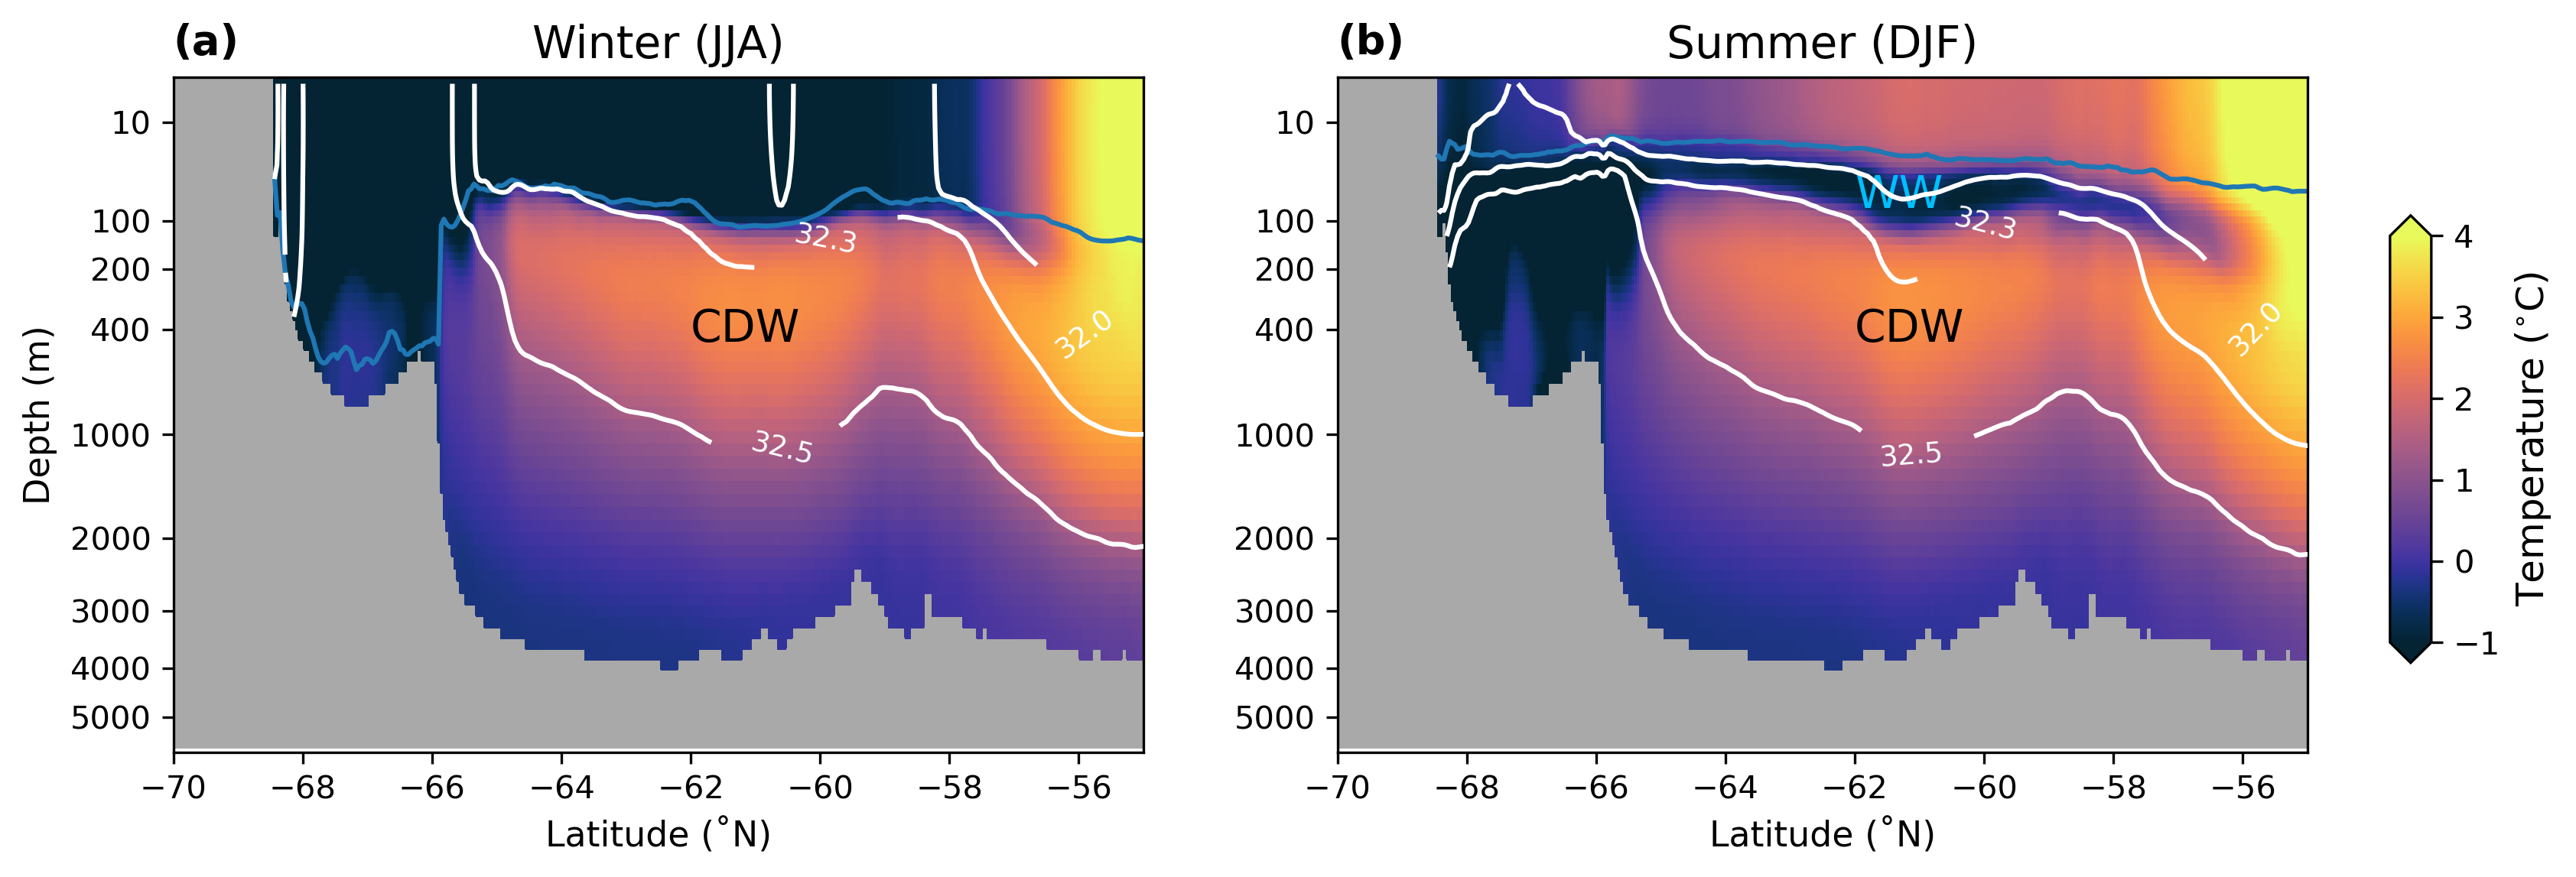

In [48]:
# Initial state of the CDW
fig = plt.figure(figsize=(12,13),dpi = 300)
projection=ccrs.SouthPolarStereo()
manual_positions1 = [
    (-60, 80), 
    (-56, 450),
    (-60,2000)
]
# transect 
ax = plt.subplot(3,2,6)
background[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (temp_summer.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_summer.sel(xt_ocean = -210,method = 'nearest').yt_ocean.values,rho_ctrl_summer[1:75,:,:].sel(xt_ocean = -210,method = 'nearest').st_ocean.values,rho_ctrl_summer.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
plt.plot(mld_summer.yt_ocean.values,mld_summer.values)
plt.yticks([10,200,400,1000,2000,3000,4000,5000], [10,200,400,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚N)', fontsize = 11)
plt.ylabel(' ', fontsize = 11)
plt.xlim(-70,-55)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
plt.text(-62,80,'WW',fontsize = 14, color = 'deepskyblue')
ax.set_title('Summer (DJF)', fontsize = 14)
ax.text(
       0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

# transect 
ax = plt.subplot(3,2,5)
background[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (temp_winter.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_winter.sel(xt_ocean = -210,method = 'nearest').yt_ocean.values,rho_ctrl_winter[1:75,:,:].sel(xt_ocean = -210,method = 'nearest').st_ocean.values,rho_ctrl_winter.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
land_2[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
plt.plot(mld_winter.yt_ocean.values,mld_winter.values)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚N)', fontsize = 11)

plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-70,-55)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
ax.set_title('Winter (JJA)', fontsize = 14)
ax.text(
       0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax_cb1 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right')

In [49]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [50]:
mid_bound = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/bound_mid_mean.nc')

In [51]:
mid_bound

<xarray.DataArray 'var' (st_ocean: 75, yt_ocean_sub01: 800)> Size: 480kB
[60000 values with dtype=float64]
Coordinates:
  * st_ocean        (st_ocean) float64 600B 0.5413 1.681 ... 5.511e+03 5.709e+03
  * yt_ocean_sub01  (yt_ocean_sub01) float64 6kB -20.0 -19.9 -19.8 ... 59.8 59.9

In [52]:
new_coord

<xarray.DataArray (st_ocean: 75, yt_ocean: 2700, xt_ocean: 3600)> Size: 6GB
[729000000 values with dtype=float64]
Coordinates:
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95

In [53]:
background_1 = xr.DataArray(
    data=np.ones_like(temp_ctrl_mean_new),
    coords=temp_ctrl_mean_new.coords,
    dims=temp_ctrl_mean_new.dims,
    name='ones_array'
)

In [54]:
manual_positions = [
    (5, 100), 
    (5, 300),
    (6,1000)
]

In [55]:
rho_ctrl_mean

<xarray.DataArray 'salt' (st_ocean: 75, yt_ocean: 666, xt_ocean: 3600)> Size: 1GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [31.3876184 , 31.38266843, 31.37965578, ..., 31.40184157,
         31.39800176, 31.39305997],
        [31.36996258, 31.36661151, 31.36454485, ..., 31.37831815,
         31.37552042, 31.37274511],
        [31.35417329, 31.35245021, 31.35105674, ..., 31.35902801,
         31.35739124, 31.35535868]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -50.09 -50.03
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

<>:53: DeprecationWarning: invalid escape sequence '\c'
<>:53: DeprecationWarning: invalid escape sequence '\c'
<unknown>:53: DeprecationWarning: invalid escape sequence '\c'
/jobfs/162838084.gadi-pbs/ipykernel_1187086/1873514978.py:53: DeprecationWarning: invalid escape sequence '\c'
  cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 12)


Text(0.0, 1.08, '(b)')

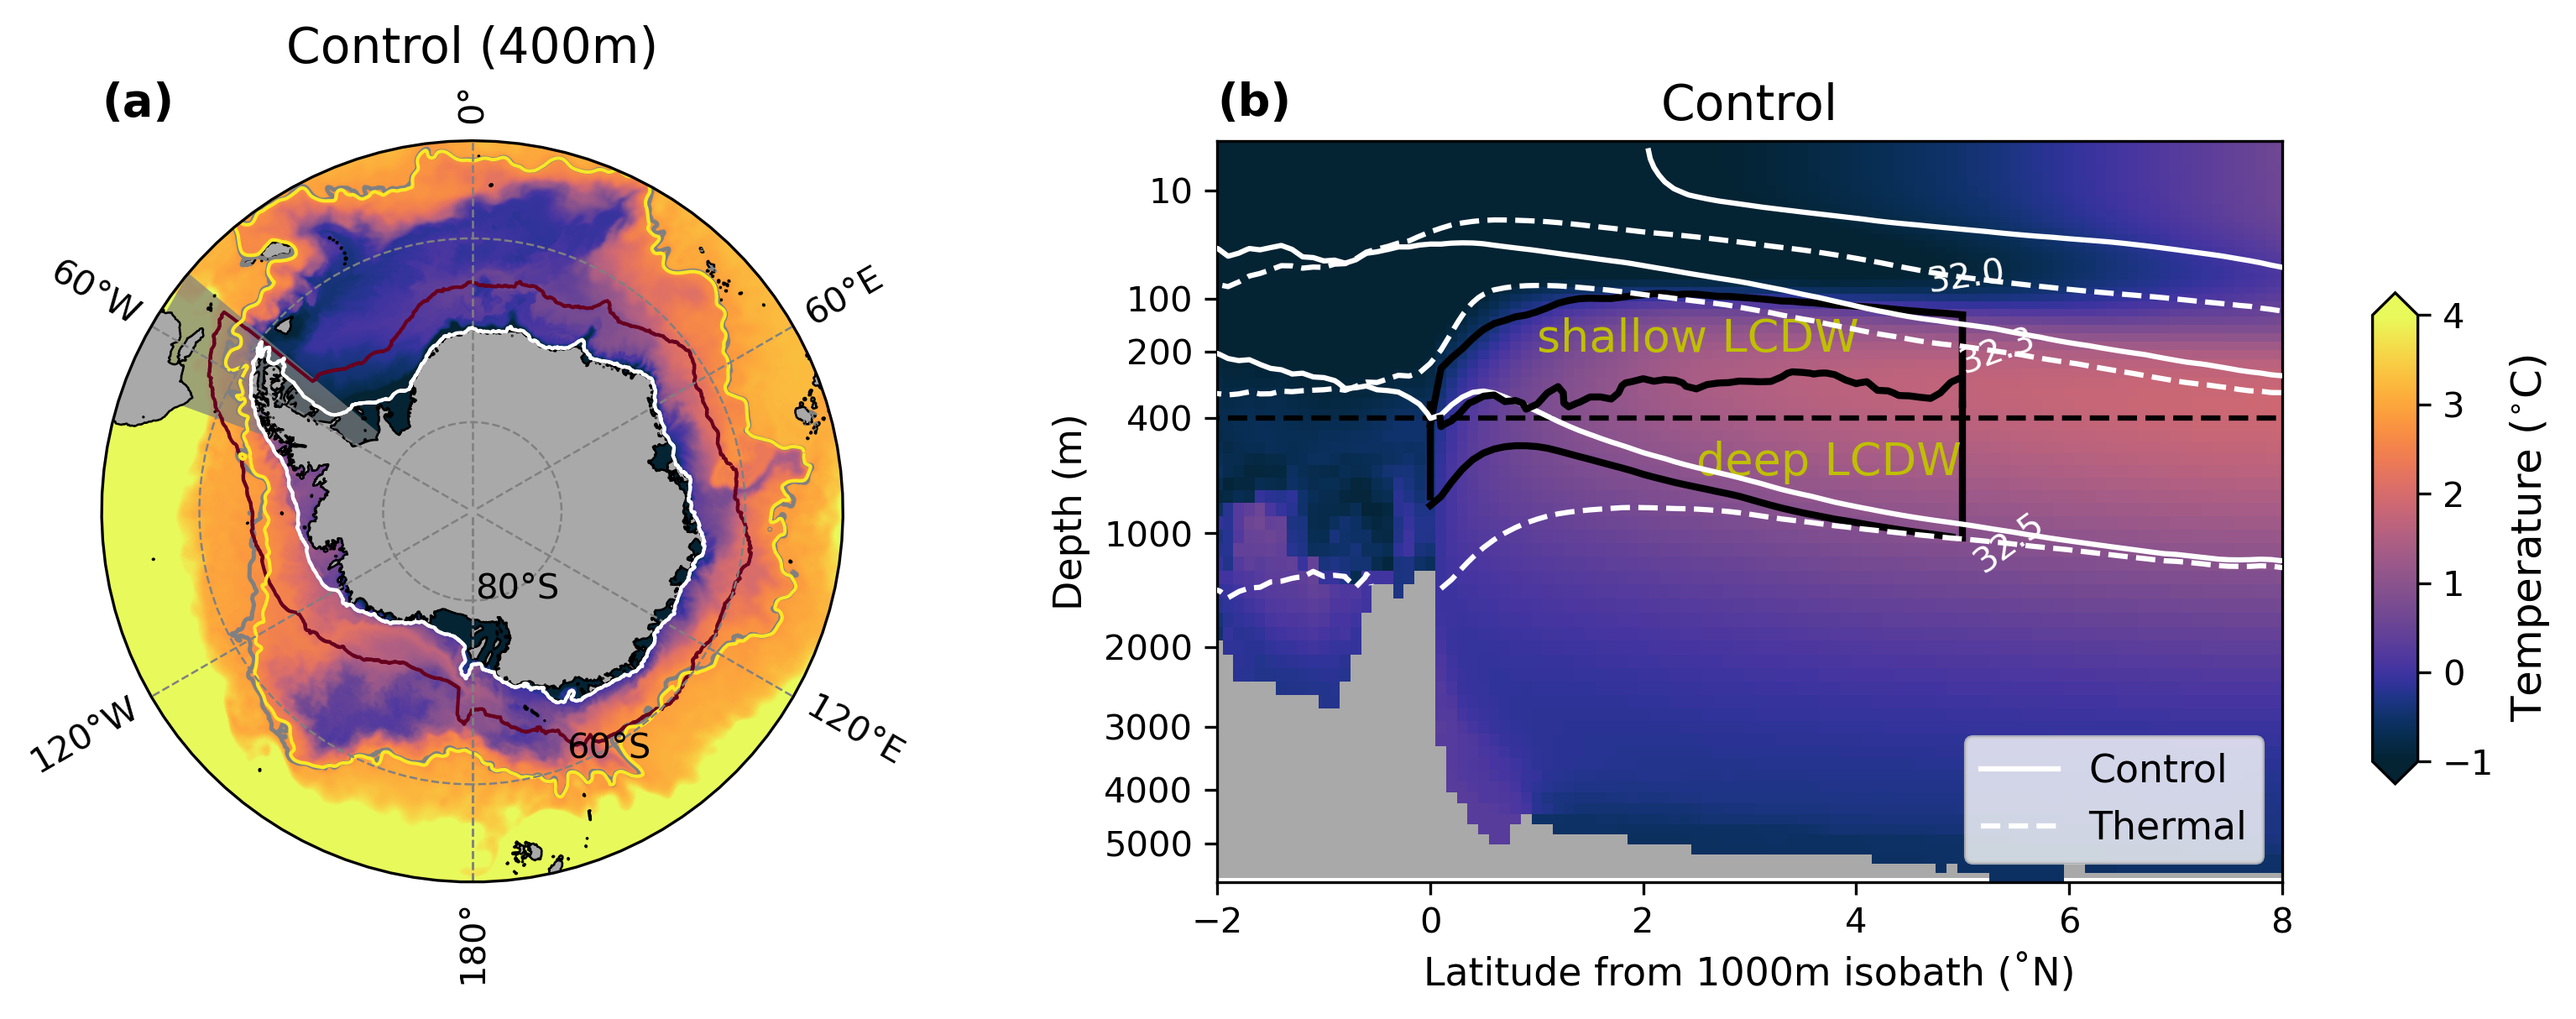

In [56]:
# Initial state of the CDW
fig = plt.figure(figsize=(12,13),dpi = 300)
projection=ccrs.SouthPolarStereo()
ax = plt.subplot(3,2,5,projection = projection,facecolor="darkgrey")
theta = np.linspace(0,2*np.pi,100)
center,radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
p1 = (data['Control']-273.15).plot(ax=ax, vmin = -1,vmax = 4, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.thermal,add_colorbar = False)

land[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
land[:,:].fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 0.6)
data['Control'].plot.contour(ax=ax, levels=[273.15+2.8], colors='grey', linewidths = 1.2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
new_coord[1,:666,:].plot.contour(ax=ax, levels=[5], linewidths = 1.,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
rho_ctrl_mean.sel(st_ocean = 400., method = 'nearest').sel(yt_ocean = slice(-90,-50)).plot.contour(ax=ax, levels=[32.3], linewidths = 1.,
                       transform=ccrs.PlateCarree(), add_colorbar=False)

lon_min, lon_max = -70, -50
lat_min, lat_max = -80, -50  # remember: south is negative

rect = mpatches.Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    facecolor="tab:grey",
    alpha=0.7,
    transform=ccrs.PlateCarree(),  # <-- IMPORTANT
)

ax.add_patch(rect)
ax.text(
        0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-80, -49, 20),
    linewidth=0.6, linestyle='--', color='0.5', draw_labels=True
)
plt.plot(x_shelf, y_shelf, linewidth=1,color='white',transform=ccrs.PlateCarree())
ax.set_title('Control (400m)', fontsize = 14)
ax_cb1 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')



# transect 
ax = plt.subplot(3,2,6)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
plt.plot(0,0,color = 'white',linestyle='-')
plt.plot(0,0,color = 'white',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower right',ncol=1)
p1 = (temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=10,inline=False,fmt='%1.1f',levels=levs_dens,manual = manual_positions,inline_spacing=-10)
plt.contour(mid_bound[:41,200:251].yt_ocean_sub01.values,mid_bound[:41,200:521].st_ocean.values,mid_bound[:,200:251].sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-2,8)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:251].yt_ocean.values, bound_up_mean[200:251].values, c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
#plt.plot([0,5],[350,350], c = 'k',linewidth=2)
plt.plot(bound_low_mean[200:250].yt_ocean_sub01.values, bound_low_mean[200:250].values, c = 'k',linewidth=2)
plt.plot([5,5],[350,bound_low_mean[250].values], c = 'k',linewidth=2)
plt.plot([0,0],[350,bound_low_mean[201].values], c = 'k',linewidth=2)
plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'y')
plt.text(2.5,650,'deep LCDW',fontsize = 13,color = 'y')
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Control', fontsize = 14)
ax.text(
       0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

In [58]:
new_coord_map = new_coord.where(new_coord<=5).where(new_coord>=0)

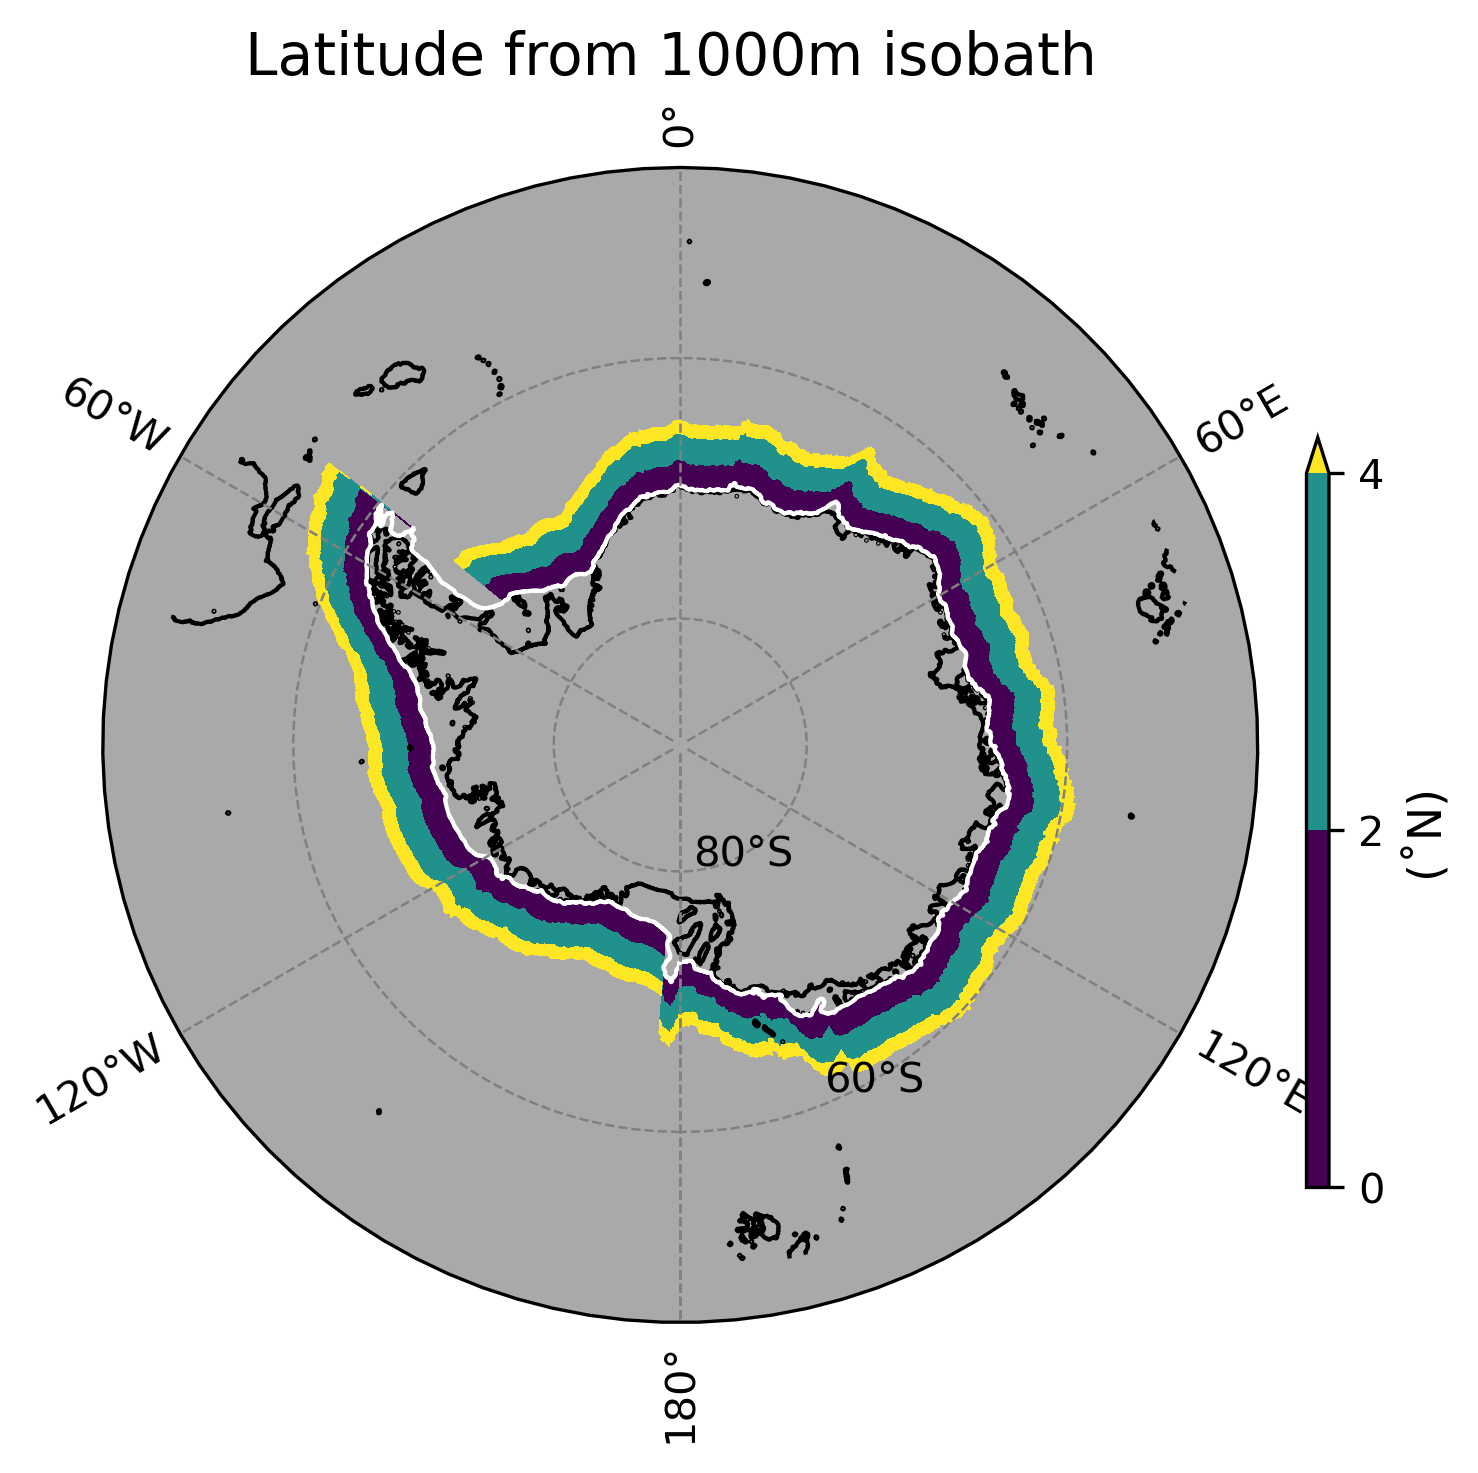

In [59]:
# For Figure S3
fig = plt.figure(figsize=(5,5),dpi = 300)
projection=ccrs.SouthPolarStereo()
ax = plt.subplot(1,1,1,projection = projection,facecolor="darkgrey")
theta = np.linspace(0,2*np.pi,100)
center,radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
p3 = new_coord_map[1,:666,:].plot.contourf(levels = np.arange(0,5,2), transform=ccrs.PlateCarree(),
                              add_colorbar = False)
#(rho_ctrl_mean[0,:,:]).plot.contour(ax=ax, levels = [32.0], transform=ccrs.PlateCarree(),
#                              linewidths = 1.,colors = 'fuchsia')
land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
land.fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 1.)
#plt.scatter(x_rho, y_rho, s=0.1,color='r',transform=ccrs.PlateCarree())
plt.plot(x_shelf, y_shelf, linewidth=1,color='white',transform=ccrs.PlateCarree())
ax.set_title('Latitude from 1000m isobath ',fontsize = 14)
ax_cb2 = plt.axes([0.93, 0.2, 0.015, 0.5])
cb = plt.colorbar(p3, cax=ax_cb2,  orientation='vertical',extend='max')
cb.ax.set_ylabel('(˚N)', fontsize = 11)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-80, -49, 20),
    linewidth=0.6, linestyle='--', color='0.5', draw_labels=True
)